In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import numpy as np
from pulp import *

# Set a clean visual style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [6]:
# Recreate dataset (same seed = identical data every time)
np.random.seed(42)
n = 50

df = pd.DataFrame({
    'supplier_id': [f'SUP_{i:03d}' for i in range(1, n+1)],
    'component_type': np.random.choice(
        ['Optical', 'Mechanical', 'Electronic', 'Pneumatic'], n),
    'lead_time_days': np.random.randint(14, 120, n),
    'lead_time_std_dev': np.random.randint(2, 20, n),
    'unit_cost_eur': np.random.randint(500, 50000, n),
    'on_time_delivery_rate': np.round(np.random.uniform(0.7, 1.0, n), 2),
    'defect_rate': np.round(np.random.uniform(0.01, 0.10, n), 3),
    'single_source': np.random.choice([True, False], n),
    'country': np.random.choice(
        ['Netherlands', 'Germany', 'Japan', 'USA', 'Taiwan'], n),
    'criticality': np.random.choice(['High', 'Medium', 'Low'], n)
})

# Recreate optimization results so 'selected' column is available
from pulp import *
prob = LpProblem("Supplier_Selection", LpMinimize)
suppliers = df['supplier_id'].tolist()
x = LpVariable.dicts("select", suppliers, cat='Binary')
risk_scores = dict(zip(df['supplier_id'],
    df['lead_time_days'] * df['defect_rate']))
prob += lpSum([risk_scores[s] * x[s] for s in suppliers])
costs = dict(zip(df['supplier_id'], df['unit_cost_eur']))
prob += lpSum([costs[s] * x[s] for s in suppliers]) <= 500000
for comp_type in df['component_type'].unique():
    relevant = df[df['component_type']==comp_type]['supplier_id'].tolist()
    prob += lpSum([x[s] for s in relevant]) >= 1
prob.solve(PULP_CBC_CMD(msg=0)) # msg=0 hides solver output

# Add selected column to df
df['selected'] = df['supplier_id'].apply(lambda s: x[s].value() == 1)

print(f"✅ Data ready — {df['selected'].sum()} suppliers selected")

✅ Data ready — 4 suppliers selected


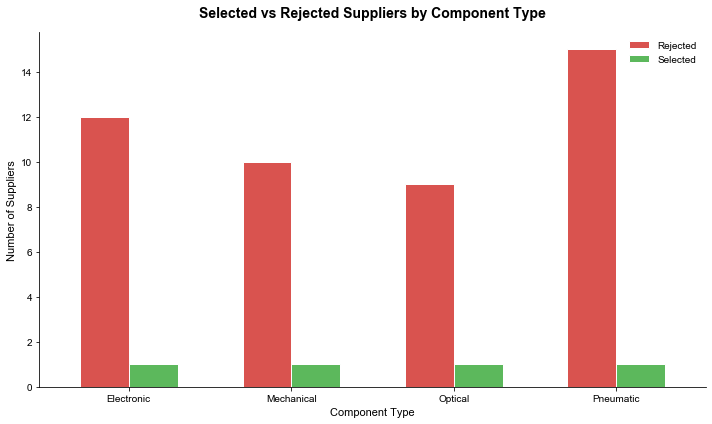

Chart 1 saved.


In [7]:
# Prepare data
df['selected'] = df['supplier_id'].apply(
    lambda s: x[s].value() == 1)

summary = df.groupby(['component_type', 'selected']).size().unstack(fill_value=0)
summary.columns = ['Rejected', 'Selected']

# Plot
fig, ax = plt.subplots()
summary.plot(kind='bar', ax=ax, 
             color=['#d9534f', '#5cb85c'], 
             edgecolor='white', width=0.6)

ax.set_title('Selected vs Rejected Suppliers by Component Type',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Component Type', fontsize=11)
ax.set_ylabel('Number of Suppliers', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Rejected', 'Selected'], frameon=False)

plt.tight_layout()
plt.savefig('chart1_selection_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

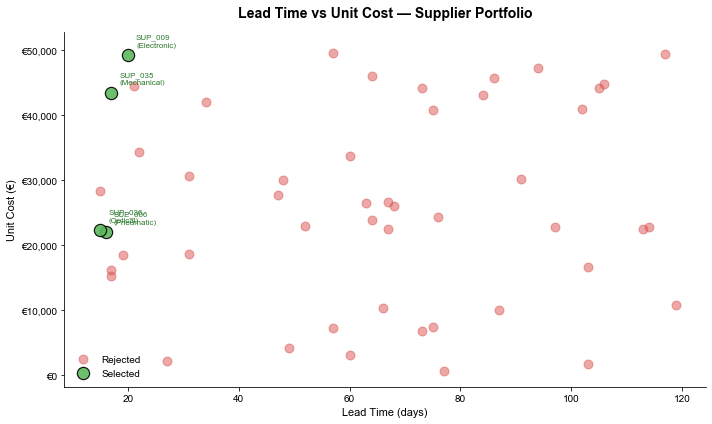

Chart 2 saved.


In [8]:
fig, ax = plt.subplots()

# Plot rejected suppliers
rejected = df[df['selected'] == False]
selected = df[df['selected'] == True]

ax.scatter(rejected['lead_time_days'], rejected['unit_cost_eur'],
           c='#d9534f', alpha=0.5, s=80, label='Rejected', zorder=2)
ax.scatter(selected['lead_time_days'], selected['unit_cost_eur'],
           c='#5cb85c', alpha=0.9, s=150, label='Selected',
           edgecolors='black', linewidth=1.2, zorder=3)

# Label selected suppliers
for _, row in selected.iterrows():
    ax.annotate(f"{row['supplier_id']}\n({row['component_type']})",
                xy=(row['lead_time_days'], row['unit_cost_eur']),
                xytext=(8, 8), textcoords='offset points',
                fontsize=8, color='#2c7a2c')

ax.set_title('Lead Time vs Unit Cost — Supplier Portfolio',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Lead Time (days)', fontsize=11)
ax.set_ylabel('Unit Cost (€)', fontsize=11)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('chart2_leadtime_vs_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

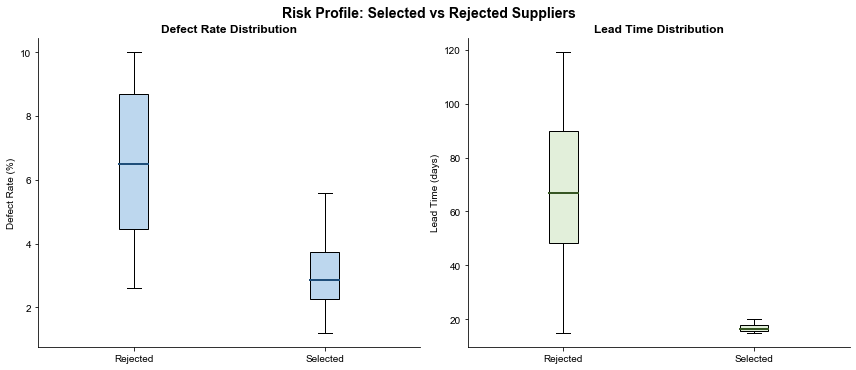

Chart 3 saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Defect rate comparison
axes[0].boxplot([rejected['defect_rate']*100, selected['defect_rate']*100],
                labels=['Rejected', 'Selected'],
                patch_artist=True,
                boxprops=dict(facecolor='#BDD7EE'),
                medianprops=dict(color='#1F4E79', linewidth=2))
axes[0].set_title('Defect Rate Distribution', 
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Defect Rate (%)', fontsize=10)

# Lead time comparison
axes[1].boxplot([rejected['lead_time_days'], selected['lead_time_days']],
                labels=['Rejected', 'Selected'],
                patch_artist=True,
                boxprops=dict(facecolor='#E2EFDA'),
                medianprops=dict(color='#375623', linewidth=2))
axes[1].set_title('Lead Time Distribution',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Lead Time (days)', fontsize=10)

fig.suptitle('Risk Profile: Selected vs Rejected Suppliers',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart3_risk_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

In [10]:
# Clean summary table of selected suppliers
print("\n" + "="*70)
print("OPTIMIZATION RESULTS SUMMARY")
print("="*70)

results_df = df[df['selected']==True][[
    'supplier_id', 'component_type', 'lead_time_days',
    'defect_rate', 'unit_cost_eur', 'criticality',
    'on_time_delivery_rate'
]].copy()

results_df['defect_rate'] = results_df['defect_rate'].apply(
    lambda x: f"{x*100:.1f}%")
results_df['on_time_delivery_rate'] = results_df['on_time_delivery_rate'].apply(
    lambda x: f"{x*100:.0f}%")
results_df['unit_cost_eur'] = results_df['unit_cost_eur'].apply(
    lambda x: f"€{x:,}")
results_df.columns = ['Supplier', 'Component', 'Lead Time (days)',
                       'Defect Rate', 'Unit Cost', 
                       'Criticality', 'On-Time Delivery']

print(results_df.to_string(index=False))
print("\n" + "="*70)
print(f"Objective: Minimize total supply chain risk score")
print(f"Constraint: Budget ≤ €500,000 | All component types covered")
print(f"Method: Mixed Integer Linear Programming (PuLP)")
print(f"Status: Optimal solution found ✓")
print("="*70)


OPTIMIZATION RESULTS SUMMARY
Supplier   Component  Lead Time (days) Defect Rate Unit Cost Criticality On-Time Delivery
 SUP_006   Pneumatic                16        3.1%   €22,018         Low              75%
 SUP_009  Electronic                20        5.6%   €49,202        High              82%
 SUP_035  Mechanical                17        2.6%   €43,441      Medium              94%
 SUP_036     Optical                15        1.2%   €22,334        High              94%

Objective: Minimize total supply chain risk score
Constraint: Budget ≤ €500,000 | All component types covered
Method: Mixed Integer Linear Programming (PuLP)
Status: Optimal solution found ✓
